Data only spans a single month but contains useful microgrid PV generation and load data

Location - John Cockerill Group’s international headquarters in Seraing, Belgium.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime
import numpy as np


In [3]:
# Set style
sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 12})

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 12})

def load_and_process_data(filename):
    df = pd.read_csv(filename)
    df.rename(columns={df.columns[0]: 'DateTime'}, inplace=True)
    df['DateTime'] = pd.to_datetime(df['DateTime'], errors='coerce')
    return df.dropna().sort_values('DateTime')

def plot_miris_data():
    try:
        load_df, pv_df = map(load_and_process_data, ['miris_load.csv', 'miris_pv.csv'])
        fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
        
        for df, ax, title, color in zip([load_df, pv_df], axes, ['Load', 'PV Generation'], ['blue', 'green']):
            for col in df.columns[1:]:
                ax.plot(df['DateTime'], df[col], linewidth=1.5, label=col, color=color)
            ax.set(title=f'MiRIS {title} Over Time', ylabel=f'{title} (kW)')
            if len(df.columns) > 2: ax.legend(loc='best')
        
        axes[-1].set_xlabel('Date')
        axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        axes[-1].xaxis.set_major_locator(mdates.AutoDateLocator())
        fig.autofmt_xdate()
        plt.tight_layout()
        plt.savefig('miris_data_visualization.png', dpi=300)
        plt.show()
        print("Visualization complete! Saved as 'miris_data_visualization.png'")
    except Exception as e:
        print(f"Error: {e}")


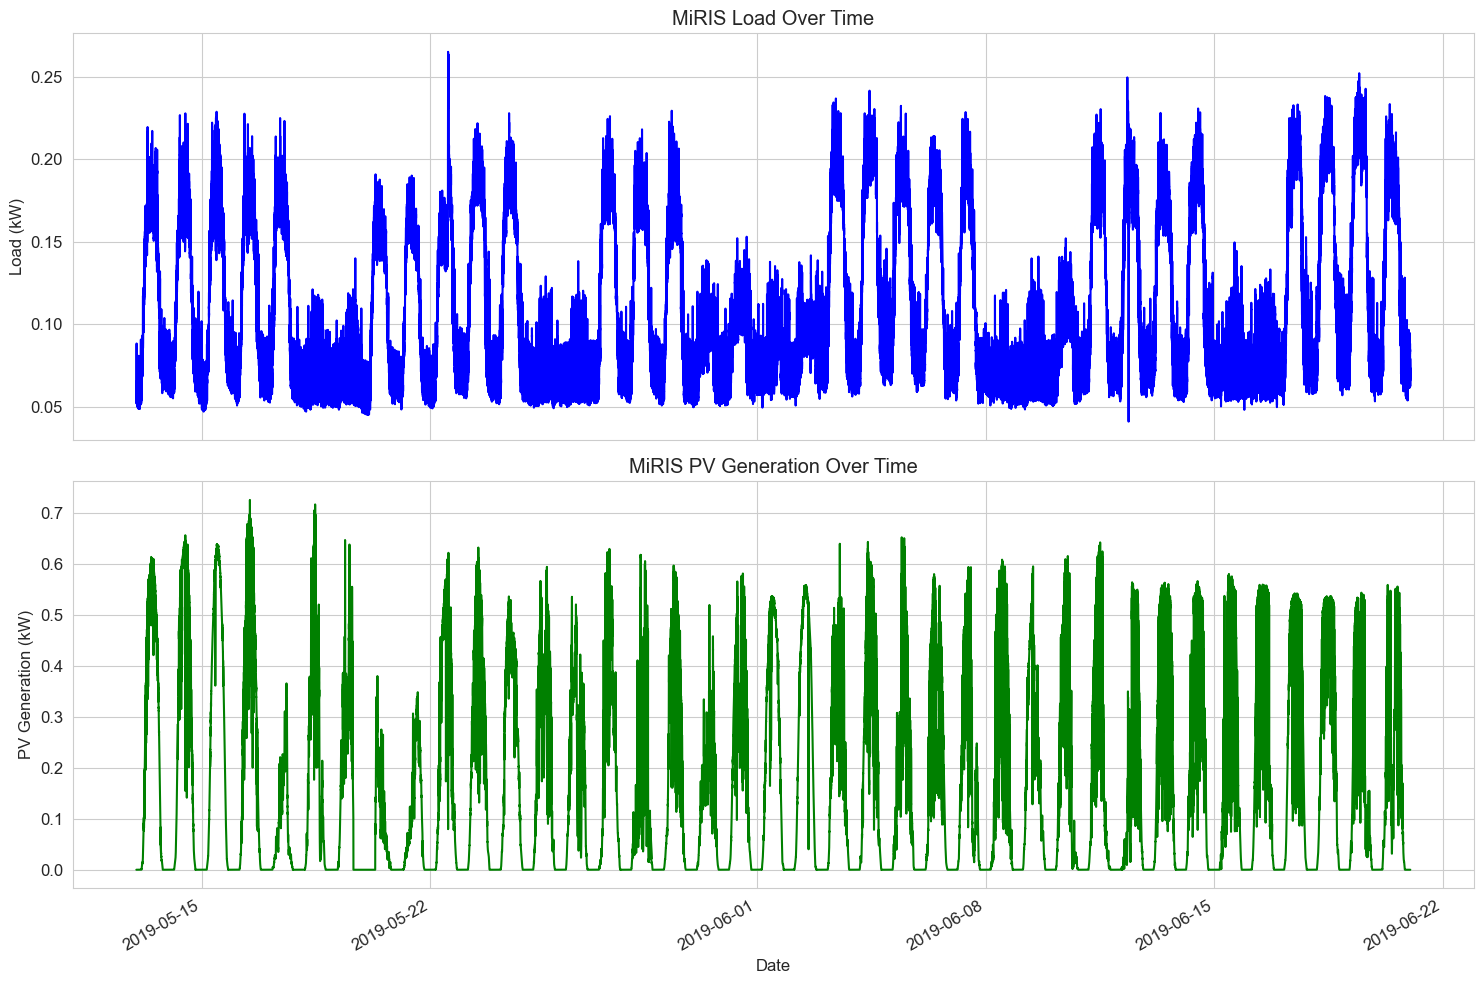

Visualization complete! Saved as 'miris_data_visualization.png'


In [4]:
plot_miris_data()